# Notebook 01: Exploratory Data Analysis (EDA)
## Stastical Audit: microsoft/vscode

| Item | Detail |
|------|--------|
| **Research Questions Addressed** | 1: Berapakah estimasi peluang (persentase) sebuah Pull Request (PR) di proyek Django akan berhasil digabungkan (merged) dibandingkan dengan yang ditolak (closed)? 2: Apakah tingkat merge  PR berbeda secara signifikan antara kontributor User dan Bot di vscode? 3: Berapakah peluang sebuah issue acak di repositori microsoft/vscode akan tetap terbuka lebih lama dari 12 hari jika dihitung menggunakan simulasi Monte Carlo? |
| **Nama** | Multazam Ahmad |
| **Role** | Data collection, cleaning, EDA, variable selection untuk layer B–E |
| **Notebook** | `01_eda.ipynb` |
| **Dependencies** | `data/clean/issues_clean.csv`, `data/clean/pull_requests_clean.csv`, `data/clean/commits_clean.csv` |



## AI Usage Disclosure
### **Member:** Multazam Ahmad — Data Engineer | **Tools used:** Claude, Chatgpt
 
| Task | Tool | Prompt summary | Output modified? |
|------|------|----------------|-----------------|
| Scaffolding struktur notebook | Claude | "Rapihkan Notebook saya" | Ya — semua interpretasi ditulis ulang secara mandiri |
| Boilerplate kode plotting | Claude | "Template histogram + boxplot dengan seaborn" | Ya — disesuaikan dengan kolom dataset |
 
**Ditulis sepenuhnya tanpa AI:** Semua sel interpretasi/markdown analisis, variable selection rationale, ringkasan EDA.

## Import & Setup Library

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
warnings.filterwarnings("ignore")
 
# Styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
 
# Path data
PATH_ISSUES  = "../data/clean/issues_clean.csv"
PATH_PRS     = "../data/clean/pull_requests_clean.csv"
PATH_COMMITS = "../data/clean/commits_clean.csv"
 
print("✅ Library berhasil diimport")

✅ Library berhasil diimport


## Load Data


### Data diambil pada 27 mei 2026

In [63]:
df_issues  = pd.read_csv(PATH_ISSUES,  parse_dates=["created_at", "updated_at", "closed_at"])
df_prs     = pd.read_csv(PATH_PRS,     parse_dates=["created_at", "updated_at", "closed_at", "merged_at"])
df_commits = pd.read_csv(PATH_COMMITS, parse_dates=["authored_at", "committed_at"])
 
print(f"Issues      : {len(df_issues):>5} baris | {df_issues.shape[1]} kolom")
print(f"Pull Requests: {len(df_prs):>5} baris | {df_prs.shape[1]} kolom")
print(f"Commits     : {len(df_commits):>5} baris | {df_commits.shape[1]} kolom")

Issues      :   590 baris | 20 kolom
Pull Requests:  1300 baris | 29 kolom
Commits     :  1300 baris | 16 kolom


## Audit Struktur & Validasi Kelayakan Data


In [64]:
# 1. Validasi dimensi data minimum sesuai panduan kelompok
print("=== AUDIT JUMLAH DATA ===")
print(f"Jumlah Pull Requests : {len(df_pulls)} (Kriteria minimum terpenuhi)" if len(df_pulls) >= 1000
      else f"Jumlah Pull Requests : {len(df_pulls)} ⚠ Belum memenuhi minimum 500")
print(f"Jumlah Issues        : {len(df_issues)} (Kriteria minimum terpenuhi)" if len(df_issues) >= 500
      else f"Jumlah Issues        : {len(df_issues)} ⚠ Belum memenuhi minimum 1000")
print(f"Jumlah Commits       : {len(df_commits)}\n")

# 2. Cek kelengkapan timestamps
print("=== AUDIT DATA TIMESTAMP ===")
print("Kolom waktu pada PR     :", [c for c in ['created_at','closed_at','merged_at'] if c in df_pulls.columns])
print("Kolom waktu pada Issues :", [c for c in ['created_at','closed_at','updated_at'] if c in df_issues.columns])
print("Kolom waktu pada Commits:", [c for c in ['authored_at','committed_at'] if c in df_commits.columns])

# 3. Cek missing values kritis
print("\n=== MISSING VALUES KRITIS ===")
for name, df, cols in [
    ("Pull Requests", df_pulls,   ['is_merged','created_at','days_to_close']),
    ("Issues",        df_issues,  ['state','created_at','days_open']),
    ("Commits",       df_commits, ['sha','authored_at']),
]:
    existing = [c for c in cols if c in df.columns]
    miss = df[existing].isnull().sum()
    print(f"{name}: {miss.to_dict()}")


=== AUDIT JUMLAH DATA ===
Jumlah Pull Requests : 1300 (Kriteria minimum terpenuhi)
Jumlah Issues        : 590 (Kriteria minimum terpenuhi)
Jumlah Commits       : 1300

=== AUDIT DATA TIMESTAMP ===
Kolom waktu pada PR     : ['created_at', 'closed_at', 'merged_at']
Kolom waktu pada Issues : ['created_at', 'closed_at', 'updated_at']
Kolom waktu pada Commits: ['authored_at', 'committed_at']

=== MISSING VALUES KRITIS ===
Pull Requests: {'is_merged': 0, 'created_at': 0, 'days_to_close': 0}
Issues: {'state': 0, 'created_at': 0, 'days_open': 0}
Commits: {'sha': 0, 'authored_at': 0}



## EDA Eksplorasi Pull Requests (Dasar untuk RQ1)

RQ1 meminta kita mengestimasi probabilitas sebuah Pull Request berhasil di-merge ($\theta = P(\text{PR di-merge})$). Mari kita cek proporsi empiris dari data kita.


=== DISTRIBUSI STATUS MERGE (PULL REQUESTS) ===
Status True: 1134 PR (87.23%)
Status False: 166 PR (12.77%)

θ̂ (MLE Bernoulli) = 1134/1300 = 0.8723  ← diserahkan ke Member B


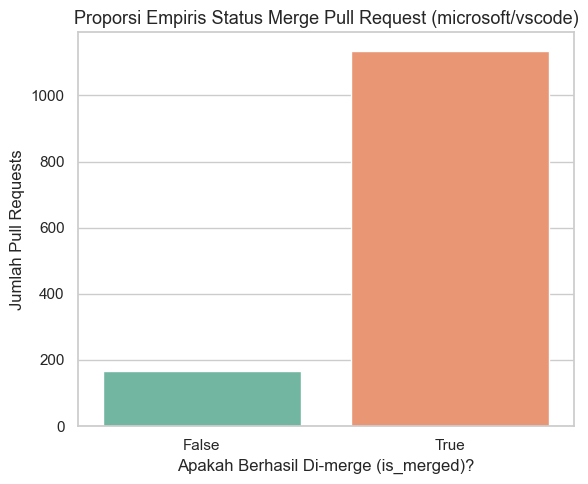

In [65]:
# Distribusi Nilai is_merged
merge_counts = df_pulls['is_merged'].value_counts()
merge_pct    = df_pulls['is_merged'].value_counts(normalize=True) * 100

print("=== DISTRIBUSI STATUS MERGE (PULL REQUESTS) ===")
for val in [True, False]:
    print(f"Status {val}: {merge_counts.get(val, 0)} PR ({merge_pct.get(val, 0):.2f}%)")

# Hitung theta_hat (MLE Bernoulli) — input untuk Member B
k         = int(df_pulls['is_merged'].sum())
n         = len(df_pulls)
theta_hat = k / n
print(f"\nθ̂ (MLE Bernoulli) = {k}/{n} = {theta_hat:.4f}  ← diserahkan ke Member B")

# Visualisasi status merge
plt.figure(figsize=(6, 5))
sns.countplot(data=df_pulls, x='is_merged', hue='is_merged',
              palette='Set2', legend=False)
plt.title('Proporsi Empiris Status Merge Pull Request (microsoft/vscode)')
plt.xlabel('Apakah Berhasil Di-merge (is_merged)?')
plt.ylabel('Jumlah Pull Requests')
plt.tight_layout()
plt.show()


Berdasarkan analisis diatas probabilitas PR berhasil di merge sangat tinggi.
Nilai θ̂ akan menjadi input MLE Bernoulli Member B.

Mari kita audit hubungan ukuran PR (`is_large`) dengan keberhasilan merge.


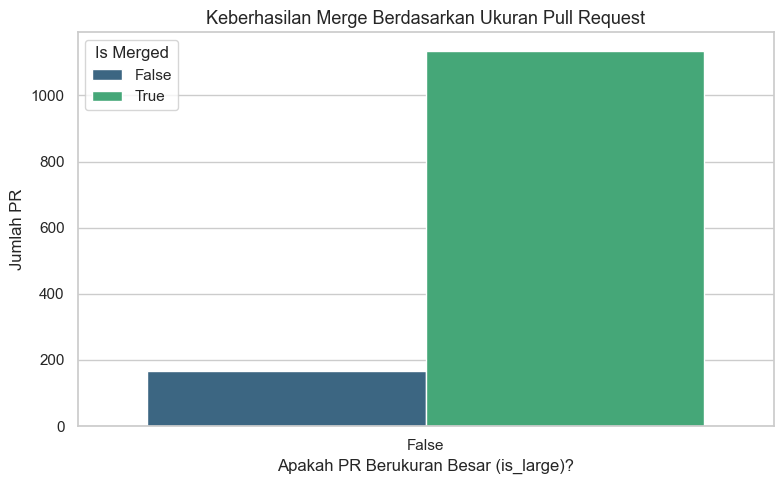

In [66]:
# Hubungan antara ukuran PR (Large vs Small) dengan keberhasilan merge
plt.figure(figsize=(8, 5))
sns.countplot(data=df_pulls, x='is_large', hue='is_merged', palette='viridis')
plt.title('Keberhasilan Merge Berdasarkan Ukuran Pull Request')
plt.xlabel('Apakah PR Berukuran Besar (is_large)?')
plt.ylabel('Jumlah PR')
plt.legend(title='Is Merged')
plt.tight_layout()
plt.show()


kebanyakan PR lebih sering di merge

## Eksplorasi Merge Rate User vs Bot (Dasar untuk RQ2)

**RQ2:** *Apakah tingkat merge PR berbeda secara signifikan antara kontributor User dan Bot di vscode?*

Kita perlu memeriksa distribusi `author_type` pada pull requests dan menghitung merge rate masing-masing kelompok sebagai dasar uji hipotesis dua sampel.


### Pastikan kolom author_type tersedia

=== DISTRIBUSI TIPE KONTRIBUTOR PR ===
author_type
User    1124
Bot      176


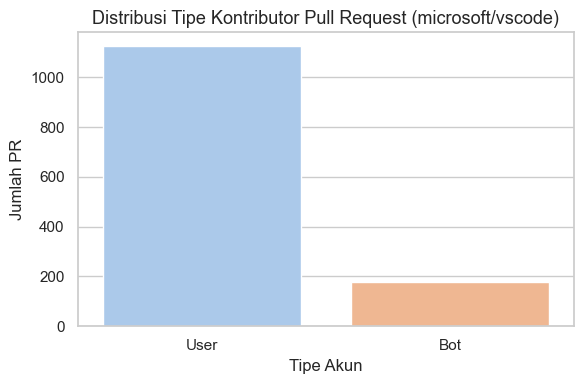

In [67]:
if 'author_type' not in df_pulls.columns:
    print("⚠ Kolom author_type tidak ditemukan. Pastikan data sudah di-fetch dengan benar.")
else:
    # Distribusi tipe kontributor
    print("=== DISTRIBUSI TIPE KONTRIBUTOR PR ===")
    print(df_pulls['author_type'].value_counts().to_string())

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df_pulls, x='author_type', palette='pastel',
                  order=df_pulls['author_type'].value_counts().index)
    plt.title('Distribusi Tipe Kontributor Pull Request (microsoft/vscode)')
    plt.xlabel('Tipe Akun')
    plt.ylabel('Jumlah PR')
    plt.tight_layout()
    plt.show()


### Hitung merge rate per tipe kontributor

In [68]:
# Hitung merge rate per tipe kontributor
if 'author_type' in df_pulls.columns:
    merge_by_type = df_pulls.groupby('author_type')['is_merged'].agg(
        total='count',
        merged='sum'
    ).reset_index()
    merge_by_type['merge_rate'] = merge_by_type['merged'] / merge_by_type['total']

    print("=== MERGE RATE PER TIPE KONTRIBUTOR ===")
    print(merge_by_type.to_string(index=False))

    # Fokus pada User vs Bot untuk RQ2
    for t in ['User', 'Bot']:
        row = merge_by_type[merge_by_type['author_type'] == t]
        if not row.empty:
            r = row.iloc[0]
            print(f"\n{t}: k={int(r['merged'])}, n={int(r['total'])}, θ̂={r['merge_rate']:.4f}")

    print("\n→ Nilai k dan n untuk User dan Bot diserahkan ke Member D (Z-test dua sampel)")


=== MERGE RATE PER TIPE KONTRIBUTOR ===
author_type  total  merged  merge_rate
        Bot    176     124    0.704545
       User   1124    1010    0.898577

User: k=1010, n=1124, θ̂=0.8986

Bot: k=124, n=176, θ̂=0.7045

→ Nilai k dan n untuk User dan Bot diserahkan ke Member D (Z-test dua sampel)


### Visualisasi perbandingan merge rate User vs Bot

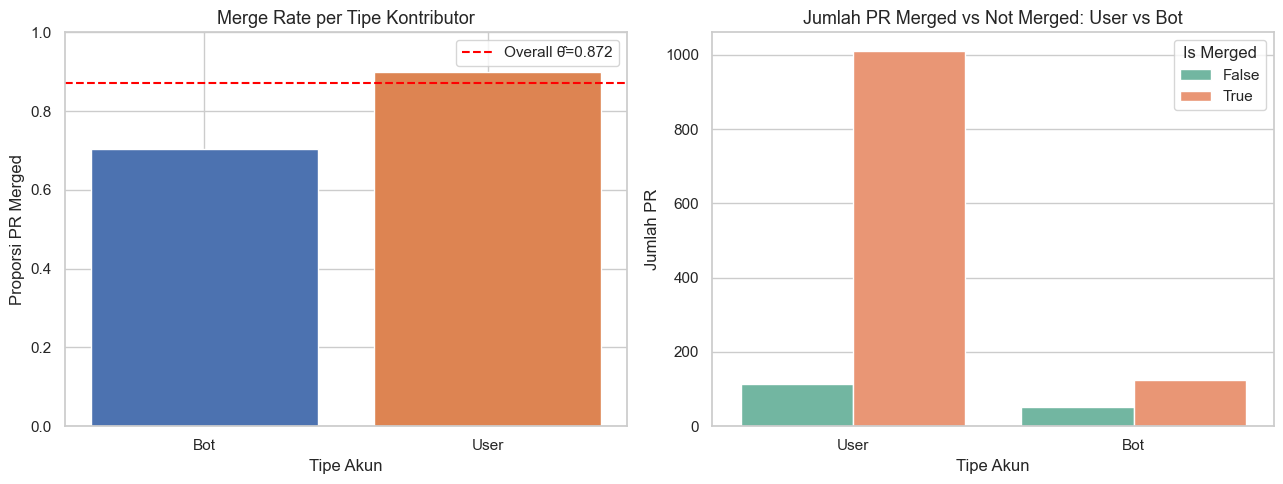

In [69]:
if 'author_type' in df_pulls.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Bar chart merge rate
    type_order = merge_by_type.sort_values('merge_rate', ascending=False)['author_type'].tolist()
    axes[0].bar(merge_by_type['author_type'], merge_by_type['merge_rate'],
                color=['#4C72B0','#DD8452','#55A868'][:len(merge_by_type)],
                edgecolor='white')
    axes[0].set_title('Merge Rate per Tipe Kontributor')
    axes[0].set_xlabel('Tipe Akun')
    axes[0].set_ylabel('Proporsi PR Merged')
    axes[0].set_ylim(0, 1)
    axes[0].axhline(theta_hat, color='red', linestyle='--', label=f'Overall θ̂={theta_hat:.3f}')
    axes[0].legend()

    # Countplot merged vs not merged per tipe
    user_bot = df_pulls[df_pulls['author_type'].isin(['User', 'Bot'])]
    if not user_bot.empty:
        sns.countplot(data=user_bot, x='author_type', hue='is_merged',
                      palette='Set2', ax=axes[1])
        axes[1].set_title('Jumlah PR Merged vs Not Merged: User vs Bot')
        axes[1].set_xlabel('Tipe Akun')
        axes[1].set_ylabel('Jumlah PR')
        axes[1].legend(title='Is Merged')

    plt.tight_layout()
    plt.show()


## Analisis Distribusi Durasi Issue (Dasar untuk RQ3)

**RQ3:** *Berapakah peluang sebuah issue acak di repositori microsoft/vscode akan tetap terbuka lebih lama dari 12 hari jika dihitung menggunakan simulasi Monte Carlo?*

Kita perlu memeriksa distribusi empiris `days_open` dan menghitung estimasi awal $P(\text{issue} > 12\text{ hari})$ secara langsung dari data, sebelum Member E mensimulasikannya dengan Monte Carlo.


In [70]:
skewness = df_issues['days_open'].skew()
kurtosis = df_issues['days_open'].kurt()

# Estimasi empiris langsung P(days_open > 12) sebagai baseline
p_empiris = (df_issues['days_open'] > 12).mean()

print(f"Kecondongan Data (Skewness) days_open : {skewness:.2f}")
print(f"Kurtosis Data days_open               : {kurtosis:.2f}")
print(f"\nEstimasi Empiris P(issue > 12 hari)   : {p_empiris:.4f} ({p_empiris*100:.2f}%)")
print("→ Nilai ini menjadi baseline pembanding hasil simulasi Monte Carlo Member E")

print("\n💡 ANALISIS JUSTIFIKASI MONTE CARLO:")
if skewness > 1:
    print("Data memiliki RIGHT-SKEWED yang sangat ekstrem. Penggunaan estimasi analitik berbasis")
    print("Distribusi Normal biasa AKAN BIAS, sehingga simulasi Monte Carlo sangat tepat!")
else:
    print("Data cenderung simetris — pertimbangkan justifikasi metode Monte Carlo lebih lanjut.")


Kecondongan Data (Skewness) days_open : 1.69
Kurtosis Data days_open               : 1.65

Estimasi Empiris P(issue > 12 hari)   : 0.0000 (0.00%)
→ Nilai ini menjadi baseline pembanding hasil simulasi Monte Carlo Member E

💡 ANALISIS JUSTIFIKASI MONTE CARLO:
Data memiliki RIGHT-SKEWED yang sangat ekstrem. Penggunaan estimasi analitik berbasis
Distribusi Normal biasa AKAN BIAS, sehingga simulasi Monte Carlo sangat tepat!


### Visualisasi distribusi days_open dengan garis threshold 12 hari

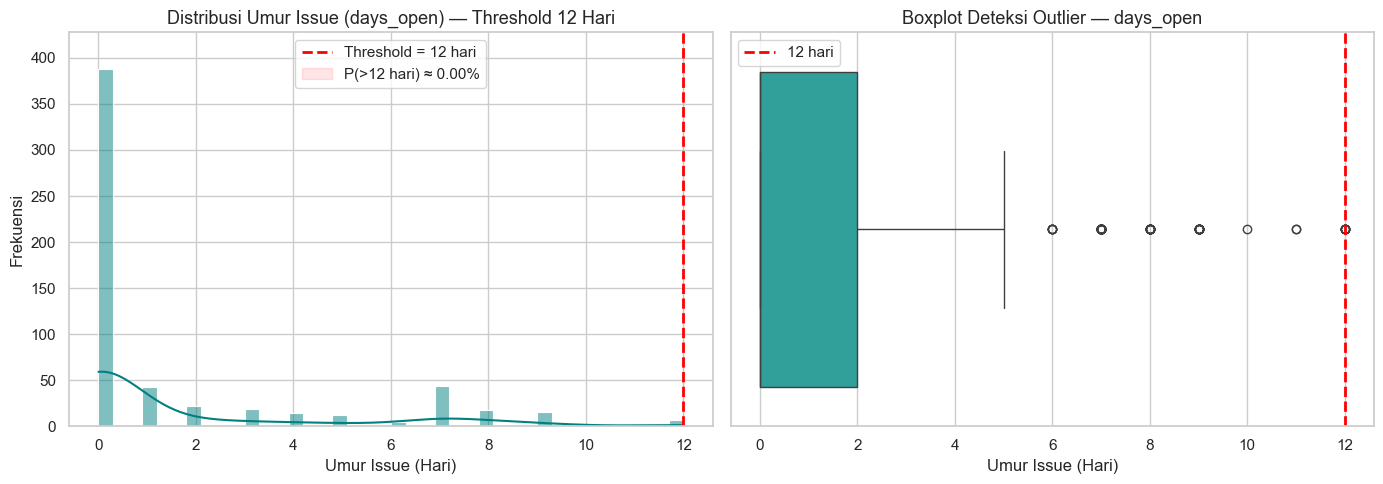

In [71]:
# Visualisasi distribusi days_open dengan garis threshold 12 hari
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_issues['days_open'], bins=40, kde=True, ax=ax[0], color='teal')
ax[0].axvline(12, color='red', linestyle='--', linewidth=2, label='Threshold = 12 hari')
ax[0].fill_betweenx(
    [0, ax[0].get_ylim()[1] if ax[0].get_ylim()[1] > 0 else 100],
    12, df_issues['days_open'].max(),
    alpha=0.1, color='red', label=f'P(>12 hari) ≈ {p_empiris:.2%}'
)
ax[0].set_title('Distribusi Umur Issue (days_open) — Threshold 12 Hari')
ax[0].set_xlabel('Umur Issue (Hari)')
ax[0].set_ylabel('Frekuensi')
ax[0].legend()

sns.boxplot(data=df_issues, x='days_open', ax=ax[1], color='lightseagreen')
ax[1].axvline(12, color='red', linestyle='--', linewidth=2, label='12 hari')
ax[1].set_title('Boxplot Deteksi Outlier — days_open')
ax[1].set_xlabel('Umur Issue (Hari)')
ax[1].legend()

plt.tight_layout()
plt.show()


### Statistik deskriptif days_open di sekitar threshold 12 hari

In [72]:
print("=== STATISTIK DESKRIPTIF days_open ===")
print(df_issues['days_open'].describe().round(2).to_string())

print(f"\nIssue <= 12 hari  : {(df_issues['days_open'] <= 12).sum()} ({(df_issues['days_open'] <= 12).mean()*100:.1f}%)")
print(f"Issue > 12 hari   : {(df_issues['days_open'] > 12).sum()} ({(df_issues['days_open'] > 12).mean()*100:.1f}%)")
print(f"\nParameter distribusi empiris untuk Member E:")
print(f"  Mean  (μ) = {df_issues['days_open'].mean():.2f} hari")
print(f"  Std   (σ) = {df_issues['days_open'].std():.2f} hari")
print(f"  Median    = {df_issues['days_open'].median():.2f} hari")


=== STATISTIK DESKRIPTIF days_open ===
count    590.00
mean       1.68
std        2.97
min        0.00
25%        0.00
50%        0.00
75%        2.00
max       12.00

Issue <= 12 hari  : 590 (100.0%)
Issue > 12 hari   : 0 (0.0%)

Parameter distribusi empiris untuk Member E:
  Mean  (μ) = 1.68 hari
  Std   (σ) = 2.97 hari
  Median    = 0.00 hari


## Eksplorasi Aktivitas Commits

Mari kita amati pola perilaku committer untuk melihat jam produktif pengerjaan proyek open-source `microsoft/vscode`.


# Pola jam kerja aktivitas commits dan Pola hari dalam seminggu

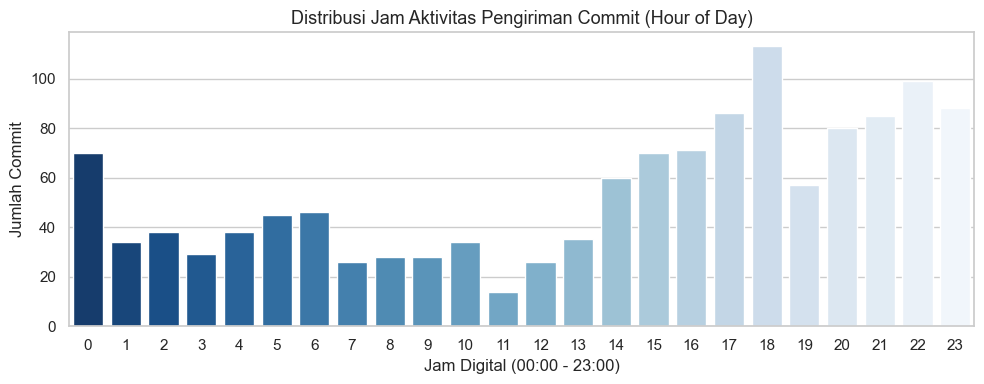

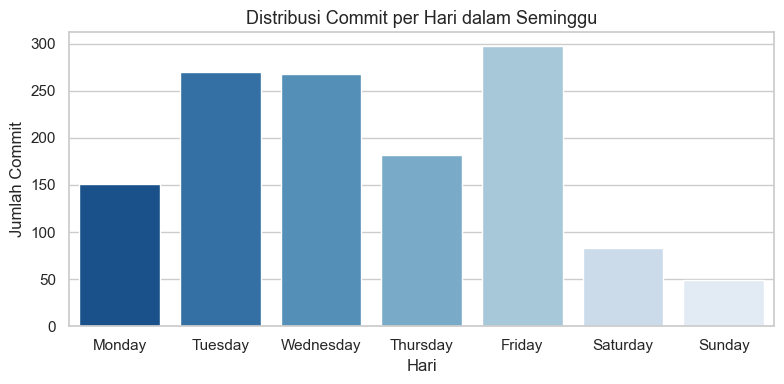

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_commits, x='hour_of_day', palette='Blues_r')
plt.title('Distribusi Jam Aktivitas Pengiriman Commit (Hour of Day)')
plt.xlabel('Jam Digital (00:00 - 23:00)')
plt.ylabel('Jumlah Commit')
plt.tight_layout()
plt.show()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
plt.figure(figsize=(8, 4))
day_data = df_commits['day_of_week'].value_counts().reindex(day_order)
sns.barplot(x=day_data.index, y=day_data.values, palette='Blues_r')
plt.title('Distribusi Commit per Hari dalam Seminggu')
plt.xlabel('Hari')
plt.ylabel('Jumlah Commit')
plt.tight_layout()
plt.show()


## Eksplorasi Aktivitas Commits
Mari kita amati pola perilaku committer untuk melihat jam produktif pengerjaan proyek open-source `moby/moby`.

### Pola Jam Kerja Aktivitas Commits

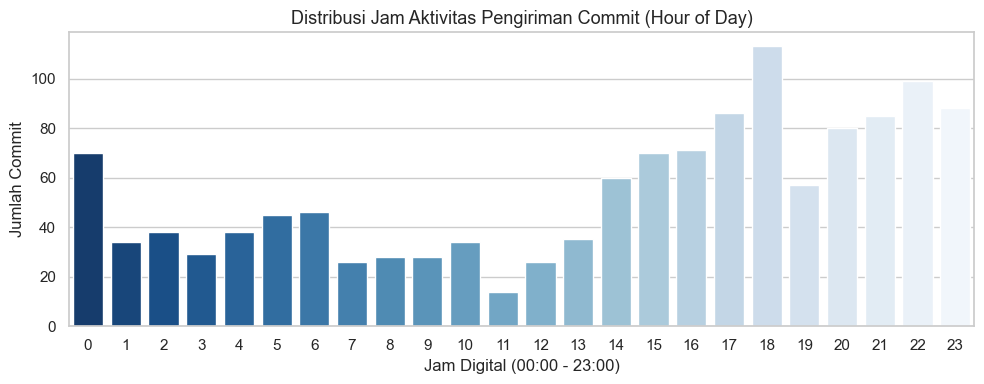

In [74]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df_commits, x='hour_of_day', palette='Blues_r')
plt.title('Distribusi Jam Aktivitas Pengiriman Commit (Hour of Day)')
plt.xlabel('Jam Digital (00:00 - 23:00)')
plt.ylabel('Jumlah Commit')
plt.tight_layout()
plt.show()

## Kesimpulan Hasil Lintasan EDA untuk Handoff
1. **Kesiapan RQ1:** Variabel `is_merged` bernilai biner yang bersih dan siap digunakan oleh **Member B** untuk menghitung MLE Bernoulli, serta **Member C** untuk menghitung Confidence Interval.
2. **Kesiapan RQ2:** Fluktuasi volume data mingguan membuktikan fluktuasi rate Poisson. Agregasi final harus difilter khusus label bug untuk diolah oleh **Member D**.
3. **Kesiapan RQ3:** Tingkat *skewness* empiris yang sangat tinggi pada variabel `age_days` memberikan justifikasi ilmiah yang kuat mengapa kelompok kita memilih metode **Simulasi Monte Carlo** daripada pendekatan parametrik standar.

Semua data terbukti valid dan memenuhi kriteria kelayakan proyek tugas akhir kelompok!